In [15]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1b

0.215808770598381


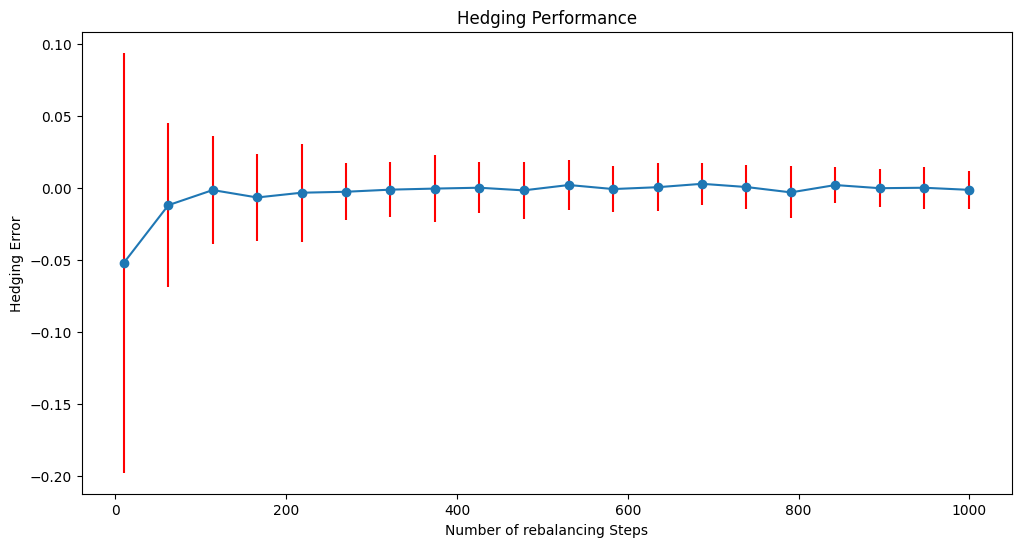

In [125]:
def Black_Scholes(S0, K, T, r, sigma, a):
    sigma = sigma * a
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    put_price = K * np.exp(-r * T) * stats.norm.cdf(-d2) - S0 * stats.norm.cdf(-d1)
    return put_price

price = Black_Scholes(S0 = 1, K = np.exp(0.02 * 30), T = 30, r = 0.02, sigma = 0.2, a = 0.5)
print(price)

def Hedge_simulator(n):
    m = 100 #Number of simulations
    T = 30
    dt = T / n
    results = np.zeros((m, 3))

    for i in range(m):
        #Initialize simulation
        S0 = 1
        A0 = 1
        K = np.exp(0.02 * 30)
        r = 0.02
        sigma = 0.2
        mu = 0.07
        a = 0.5

        Vpf = Black_Scholes(S0, K, T, r, sigma, a)

        d1 = (np.log(A0 / K) + (r + 0.5 * (sigma * a) ** 2) * T) / ((sigma * a) * np.sqrt(T))
        h_S = (stats.norm.cdf(d1) - 1) * a *  A0 / S0
        h_B = Vpf - h_S * S0
        
        S = S0
        A = A0
        for j in range(n):
            dW = np.random.normal(0, np.sqrt(dt))
            S = S * np.exp((mu - 0.5 * sigma**2) * dt + sigma * dW)
            A = A * np.exp((a * mu + r - a * r - 0.5 * a**2 * sigma**2) * dt + a * sigma * dW)
            Vpf = h_S * S + h_B * np.exp(r * dt)

            #Rebalance the hedge
            tau = T - (j + 1) * dt # Time remaining
            if tau > 0:
                d1 = (np.log(A / K) + (r + 0.5 * (sigma * a) ** 2) * tau) / ((sigma * a) * np.sqrt(tau))
                h_S = (stats.norm.cdf(d1) - 1) * a *  A / S
                h_B = Vpf - h_S * S

        
        #Save results
        results[i, 0] = Vpf
        results[i, 1] = max(K - A, 0)
        results[i, 2] = S

    return results


n_vals = np.linspace(10, 1000, 20, dtype=int)
errors = []
errors_std = []
for n in n_vals:
    results = Hedge_simulator(n)
    error = np.mean(results[:, 0] - results[:, 1])
    error_std = np.std(results[:, 0] - results[:, 1])
    errors.append(error)
    errors_std.append(error_std)


plt.figure(figsize=(12, 6))
plt.errorbar(n_vals, errors, yerr = errors_std, ecolor = 'red', marker='o')
#plt.plot(n_vals, errors, marker='o')
plt.xlabel('Number of rebalancing Steps')
plt.ylabel('Hedging Error')
plt.title('Hedging Performance')
plt.show()

# 1c

In [17]:
S0 = 1
A0 = 1
T = 30
r = 0.02
K = np.exp(r * T)
sigma = 0.2
mu = 0.07
a = 0.5

#First expression
u = (np.log(K / A0) - (a * mu + r - a * r - 0.5 * a**2 * sigma**2) * T)/(sigma * a * np.sqrt(T))
first = np.exp(-r * T) * K * stats.norm.cdf(u) - A0 * np.exp((a * mu - a * r) * T) * stats.norm.cdf(u - sigma * a * np.sqrt(T))
print(first)

#Second expression
v = (np.log(K / S0**a) - (a * r - 0.5 * sigma**2 * a) * T)/(sigma * a * np.sqrt(T))
second = np.exp(-r * T) * K * stats.norm.cdf(v) - A0 * np.exp((a * r - r - 0.5 * sigma**2 * (a - a**2)) * T) * stats.norm.cdf(v - sigma * a * np.sqrt(T))
print(second)

#Third expression
d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)
third = a * (K * np.exp(-r * T) * stats.norm.cdf(-d2) - S0 * stats.norm.cdf(-d1))
print(third)

0.030442219432287962
0.4118609435922049
0.20805878961481744


# 1e

In [114]:
S0 = 1
A0 = 1
T = 30
r = 0.02
K = np.exp(r * T)
sigma = 0.2
a = 0.5

gT = A0/(S0**a) * np.exp((r - a * r + 0.5 * a * (sigma**2) - 0.5 * a**2 * (sigma**2)) * T)
C = (K/gT)**(1/a) 

N_vals = [10, 50, 100, 500, 1000]
delta_weight = a * gT * (C)**(a - 1)

def f_double_prime(k):
    return a * (1 - a) * gT * k**(a - 2)

for N in N_vals:
    strikes = np.linspace(0.0001, C, N)
    dk = strikes[1] - strikes[0]
    portfolio_price = sum(f_double_prime(k) * dk * Black_Scholes(S0, k, T, r, sigma, a = 1) for k in strikes[:-1])
    portfolio_price += delta_weight * Black_Scholes(S0, C, T, r, sigma, a = 1)

    print(f"Replicated Portfolio Price: {portfolio_price} for N = {N}")

Replicated Portfolio Price: 0.2112653409383191 for N = 10
Replicated Portfolio Price: 0.21496727357130982 for N = 50
Replicated Portfolio Price: 0.21539200051616972 for N = 100
Replicated Portfolio Price: 0.21572604650269972 for N = 500
Replicated Portfolio Price: 0.215767447602271 for N = 1000


# 1g

In [ ]:
import sys
sys.path.append('anderson-lake-python-master')
from pricers import anderson_lake_expsinh
from models import HestonModel
from options import EuropeanCallOption

a = 0.5
r = 0.02
T = 30
V0 = a**2 * 0.2**2
theta = a**2 * 0.2**2
kappa = 2.0
epsilon = a * 1
rho = -0.5
A0 = 1
K = np.exp(r * T)

#Forward price
F = A0 * np.exp(r * T)

model = HestonModel(F, V0, kappa, theta, epsilon, rho, r)
option = EuropeanCallOption(T, K)

call = anderson_lake_expsinh(model, option)
print(f"Heston call price: {call}")

Heston call price: 0.20391690253223158


# 1h

In [ ]:
a = 1
K = np.exp(r * T)
gT = A0/(S0**a) * np.exp((r - a * r + 0.5 * a * (sigma**2) - 0.5 * a**2 * (sigma**2)) * T)
C = (K / gT)**(1/a)

model_S = HestonModel(forward=S0*np.exp(r*T), vol=0.20, kappa=2.0, 
                      theta=0.20, sigma=1.0, rho=-0.5, rate=r)

def get_put_price(k):
    opt = EuropeanCallOption(T, k)
    call = anderson_lake_expsinh(model_S, opt)
    return call

N = 100
strikes = np.linspace(0.1, C, N)
dk = strikes[1] - strikes[0]

integral_part = 0
for k in strikes[:-1]:
    integral_part += a * (1 - a) * gT * (k**(a - 2)) * get_put_price(k) * dk

delta_weight = a * gT * (C**(a - 1))
boundary_part = delta_weight * get_put_price(C)

replicated_price = integral_part + boundary_part
print(f"Replicated Portfolio Price: {replicated_price}")


NoConvergenceError: negative partial sum did not converge